In [1]:
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt

In [2]:
path2ac = '/home/yec23006/projects/research/KneeGrowthPlate/Embedding/image/png/CCC_K10_F1_L2'
achigh = cv2.imread(os.path.join(path2ac, 'AC_high.png'))
aclow = cv2.imread(os.path.join(path2ac, 'AC_low.png'))

D0CML07 = cv2.imread(os.path.join(path2ac, '07_D0CML.png'))
D1CAC15 = cv2.imread(os.path.join(path2ac, '15_D1CAC.png'))
D0BAP11 = cv2.imread(os.path.join(path2ac, '11_D0BAP.png'))
D1BAC17 = cv2.imread(os.path.join(path2ac, '17_D1BAC.png'))

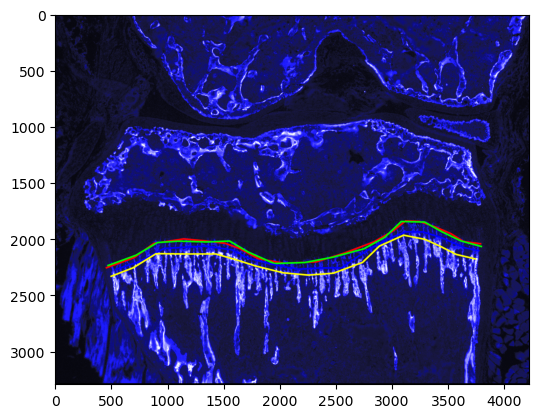

In [3]:
### Red for line 07
### Green for line 15
### Blue for line 11
### Yellow for line 17
imgWline = achigh.copy()

mask07 = D0CML07[:, :, 0] != 0
imgWline[mask07] = np.array([255, 0, 0]) 
mask15 = D1CAC15[:, :, 0] != 0
imgWline[mask15] = np.array([0, 255, 0])
mask11 = D0BAP11[:, :, 0] != 0
imgWline[mask11] = np.array([0, 0, 255])
mask17 = D1BAC17[:, :, 0] != 0
imgWline[mask17] = np.array([255, 255, 0])
plt.imshow(imgWline)
plt.show()

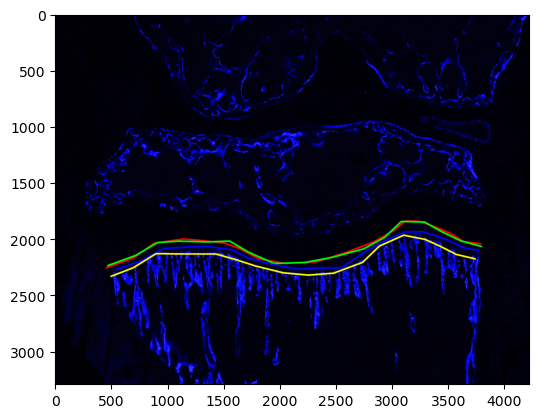

In [4]:
### Red for line 07
### Green for line 15
### Blue for line 11
### Yellow for line 17
imgWline = aclow.copy()
mask07 = D0CML07[:, :, 0] != 0
imgWline[mask07] = np.array([255, 0, 0]) 
mask15 = D1CAC15[:, :, 0] != 0
imgWline[mask15] = np.array([0, 255, 0])
mask11 = D0BAP11[:, :, 0] != 0
imgWline[mask11] = np.array([0, 0, 255])
mask17 = D1BAC17[:, :, 0] != 0
imgWline[mask17] = np.array([255, 255, 0])
plt.imshow(imgWline)
plt.show()

In [112]:
def getRangePoints(mask, type):
    # Get range points
    # type == bottom : the case of most bottom 
    # type == top : the case of most top
    roi_idx_x, roi_idx_y = np.where(mask==1)
    unique_y = np.unique(roi_idx_y)
    minmax_y = [np.min(unique_y), np.max(unique_y)]
    points_list = []

    for y in minmax_y:
        x_list = []
        overlapped_y_idx = np.where(np.array(roi_idx_y) ==y)[0]
        x_list = [roi_idx_x[i] for i in overlapped_y_idx]
        points_list.append([x_list, y])
    rangepoints = []
    for xy in points_list:
        if type == 'bottom':
            pair = (max(xy[0]), xy[1])
        else:
            pair = (min(xy[0]), xy[1])
        rangepoints.append(pair)

    return rangepoints
    
def draw_line(mask, type, thickness=1):
    """
    mask : closed binary mask of ROI object (0, 1)
    outline : binary image (0, 1)
    return : connected most bottom line or top line
    """
    outline = (getBorder(np.array(mask*255, np.uint8))).astype(np.uint8)
    point_a, point_b = getRangePoints(mask, type)

    broken_outline = np.copy(outline)
    broken_outline[point_a] = 0
    broken_outline[point_b] = 0

    contours, _ = cv2.findContours(broken_outline, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    areaArray = []
    for c in contours:
        area = cv2.contourArea(c)
        areaArray.append(area)

    min_contour = min(contours, key=cv2.contourArea)
    min_line_img = np.zeros(broken_outline.shape)
    cv2.drawContours(min_line_img, [min_contour], -1, 255, -1)

    max_contour = min(contours, key=cv2.contourArea)
    max_line_img = np.zeros(broken_outline.shape)
    cv2.drawContours(max_line_img, [max_contour], -1, 255, -1)

    if np.sum(min_line_img, axis=1)[0] > 0:
        line_img = max_line_img
    else:
        line_img = min_line_img

    thickened_line = cv2.dilate(line_img, np.ones((thickness, thickness), np.uint8))
    
    return thickened_line

def getBorder(image, width=1):
    bg = np.zeros(image.shape)
    contours, _ = cv2.findContours(image.copy(), cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)
    biggest = 0
    bigcontour = None
    for contour in contours:
        area = cv2.contourArea(contour) 
        if area > biggest:
            biggest = area
            bigcontour = contour
    return cv2.drawContours(bg, [bigcontour], 0, (255, 255, 255), width).astype(bool) 

# AC Lines

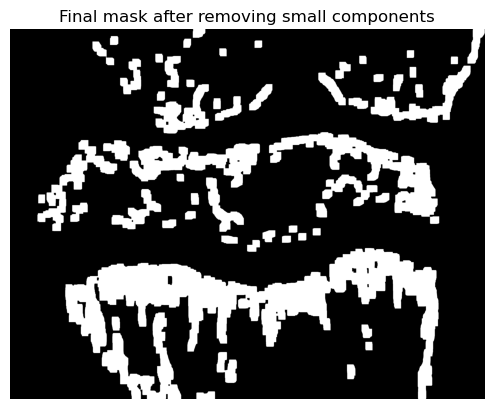

In [150]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.measure import label, regionprops

# Gaussian blur
achigh_gray = cv2.cvtColor(achigh, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(achigh_gray, (7, 7), 0)
blurred = np.where(blurred < 150, 0, blurred) # 150 / 80

# Sobel edge detection
sobelx = cv2.Sobel(blurred, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(blurred, cv2.CV_64F, 0, 1, ksize=5)
magnitude = cv2.magnitude(sobelx, sobely)
magnitude = cv2.convertScaleAbs(magnitude)

# Threshold
threshold = 200
edges = cv2.threshold(magnitude, threshold, 255, cv2.THRESH_BINARY)[1]

# Remove small components
labeled = label(edges)
min_size = 200  # tweak as needed
filtered = np.zeros_like(edges, dtype=np.uint8)
for region in regionprops(labeled):
    if region.area >= min_size:
        filtered[labeled == region.label] = 255

kernel1 = np.ones((7, 7), np.uint8)
kernel2 = np.ones((2, 2), np.uint8)
dilated_image = cv2.dilate(filtered, kernel1, iterations=10)
closed_img = cv2.erode(dilated_image, kernel2, iterations=10)

# Show the result
plt.figure()
plt.imshow(closed_img, cmap='gray')
plt.title("Final mask after removing small components")
plt.axis('off')
plt.show()


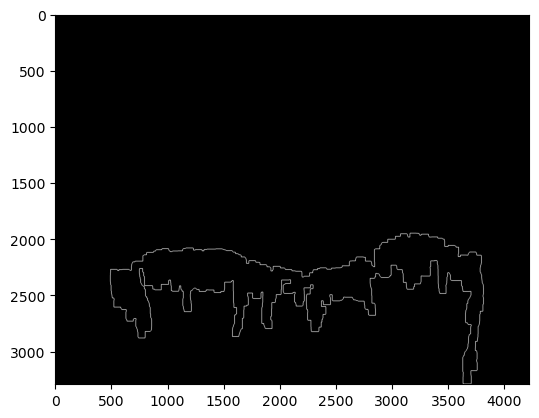

In [151]:
contours, _ = cv2.findContours(closed_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

# Select the largest contour
largest_contour = max(contours, key=cv2.contourArea)

# Create a mask for the largest contour
largest_contour_mask = np.zeros_like(closed_img)
cv2.drawContours(largest_contour_mask, [largest_contour], -1, 255, -1)

# Display the result
edge = getBordered(largest_contour_mask, 3)
plt.figure()
plt.imshow(edge, 'gray')
plt.show()

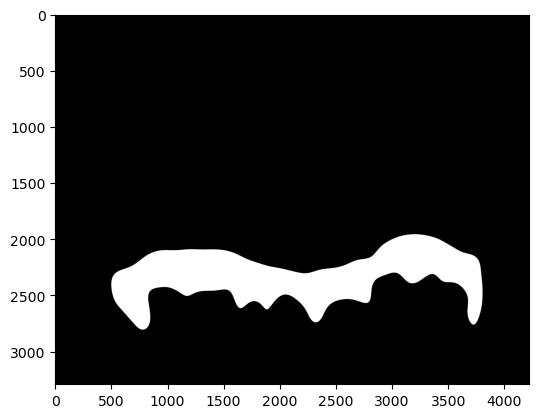

In [152]:
from scipy.ndimage import gaussian_filter

xscipy=gaussian_filter(largest_contour_mask, sigma=70, mode="wrap")
thres_xscipy = np.where(xscipy>255*0.5, 255, 0)

labeled = label(thres_xscipy)
regions = regionprops(labeled)
largest_region = max(regions, key=lambda r: r.area)
largest_mask = (labeled == largest_region.label) # .astype(np.uint8) * 255

plt.imshow(largest_mask, 'gray')
cv2.imwrite('/home/yec23006/projects/research/KneeGrowthPlate/Embedding/results/AC/mask1.png', largest_mask.astype(np.uint8)*255)
plt.show()

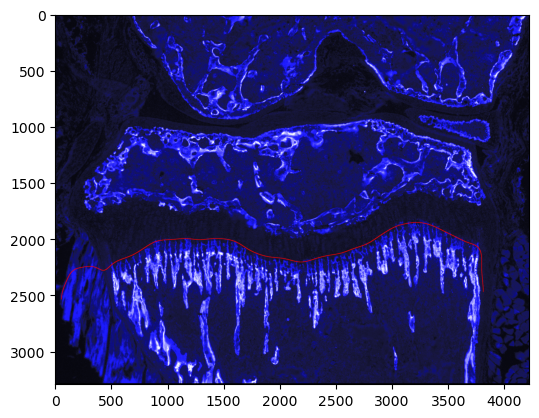

In [132]:
line = draw_line(largest_mask, type='top', thickness=5)
line = line > 0
achigh_overlap = np.copy(achigh)
achigh_overlap[line] = np.array([255, 0, 0])
cv2.imwrite('/home/yec23006/projects/research/KneeGrowthPlate/Embedding/results/AC/ac2.png', cv2.cvtColor(achigh_overlap, cv2.COLOR_RGB2BGR))
plt.imshow(achigh_overlap, 'gray')